In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from sentinel.ml_logic.metrics import corrected_event_f05
from tqdm import tqdm
import itertools

# --- config
VAL_FRAC = 0.2  # temporal split
Q_LOW_GRID  = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]
Q_HIGH_GRID = [0.99, 0.995, 0.996, 0.997, 0.998]

DATA_DIR        = "../data"
RAW_DIR         = DATA_DIR + "/raw"
train_path = RAW_DIR + "/train.parquet"
test_path = RAW_DIR + "/test.parquet"
column_names = ['channel_' + str(n) for n in range(41, 46+1)]


# --- 1. load only required columns
cols = ['id', 'is_anomaly'] + column_names

train = pq.read_table(train_path, columns=cols).to_pandas().set_index('id')
test  = pq.read_table(test_path,  columns=['id'] + column_names).to_pandas().set_index('id')

# --- 2. temporal split (no shuffle)
split_idx = int(len(train) * (1 - VAL_FRAC))

train_tr = train.iloc[:split_idx]
train_val = train.iloc[split_idx:]

X_tr = train_tr[column_names]
X_val = train_val[column_names]
y_val = train_val['is_anomaly'].values

# --- 3. threshold function
def predict_with_thresholds(df, low, high):
    return ((df < low) | (df > high)).any(axis=1).astype(int).values


In [2]:
# --- 4. grid search

best_score = -1
best_params = None
best_thresholds = None
best_metrics = None

grid = list(itertools.product(Q_LOW_GRID, Q_HIGH_GRID))

for q_low, q_high in tqdm(grid, desc="Threshold search"):
        
    low  = X_tr.quantile(q_low)
    high = X_tr.quantile(q_high)

    y_pred_val = predict_with_thresholds(X_val, low, high)

    metric = corrected_event_f05(y_val, y_pred_val)
    score = metric["f_score"]

    if score > best_score:
        best_score = score
        best_params = (q_low, q_high)
        best_thresholds = (low, high)
        best_metrics = metric

print(f"Best params: q_low={best_params[0]}, q_high={best_params[1]}")
print(f"Best F0.5: {best_score:.4f}")

# --- 5. refit thresholds on FULL train with best quantile params
q_low_best, q_high_best = best_params
low  = train[column_names].quantile(q_low_best)
high = train[column_names].quantile(q_high_best)
print(f'Refitted: q_low={q_low_best}, q_high={q_high_best}')

# --- 6. inference on test
y_pred_test = predict_with_thresholds(test[column_names], low, high)

# --- 7. save submission
from pathlib import Path as _P
_P('../submissions').mkdir(exist_ok=True)
sub = pd.DataFrame({'id': test.index, 'is_anomaly': y_pred_test})
sub.to_csv('../submissions/ek_no_model_thr.csv', index=False)
print(f'Saved → ../submissions/ek_no_model_thr.csv')
print(f'Predicted anomaly rate: {y_pred_test.mean():.4%}')

best_metrics

Threshold search: 100%|██████████| 25/25 [03:58<00:00,  9.56s/it]


Best params: q_low=0.0001, q_high=0.997
Best F0.5: 0.6977
Refitted: q_low=0.0001, q_high=0.997
Saved → ../submissions/ek_no_model_thr.csv
Predicted anomaly rate: 0.0036%


{'f_score': 0.697674,
 'f1': 0.697674,
 'precision': 1.0,
 'recall': 0.315789,
 'tp_events': 12,
 'fn_events': 26,
 'fp_pred_events': 0,
 'fp_samples': 0,
 'tnr': 1.0}

## Viz — channel signal · thresholds · rejected zones · GT anomalies

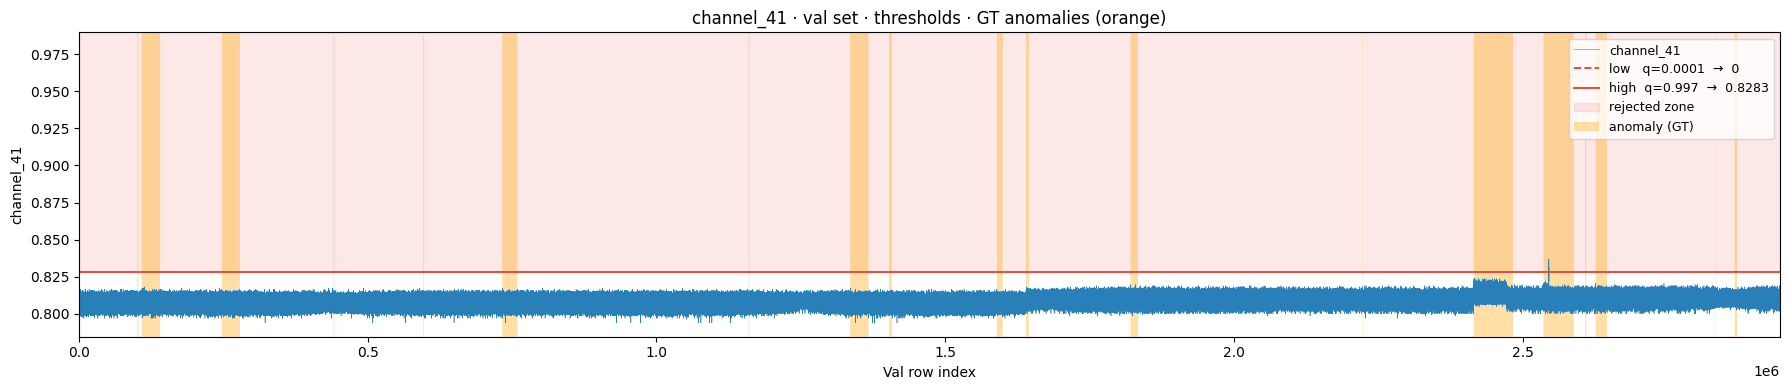

In [3]:
import matplotlib.pyplot as plt

SHOW_CH = column_names[0]   # change index to inspect other channels

vals   = X_val[SHOW_CH].values
labels = y_val

# subsample the line for speed; fill_between uses full-resolution labels
STEP = max(1, len(vals) // 80_000)
idx  = np.arange(0, len(vals), STEP)

y_lo = vals.min()
y_hi = vals.max()
pad  = (y_hi - y_lo) * 0.05

ch_low  = float(low[SHOW_CH])
ch_high = float(high[SHOW_CH])

fig, ax = plt.subplots(figsize=(18, 4))

# signal (subsampled)
ax.plot(idx, vals[idx], lw=0.4, color='#2980b9', label=SHOW_CH)

# threshold lines
ax.axhline(ch_low,  color='#e74c3c', lw=1.4, ls='--',
           label=f'low   q={best_params[0]}  →  {ch_low:.4g}')
ax.axhline(ch_high, color='#e74c3c', lw=1.4, ls='-',
           label=f'high  q={best_params[1]}  →  {ch_high:.4g}')

# semi-transparent rejected zones
xs = [0, len(vals)]
ax.fill_between(xs, y_lo - pad, ch_low,  color='#e74c3c', alpha=0.12)
ax.fill_between(xs, ch_high, y_hi + pad, color='#e74c3c', alpha=0.12,
                label='rejected zone')

# ground-truth anomaly spans
ax.fill_between(np.arange(len(labels)), y_lo - pad, y_hi + pad,
                where=(labels == 1),
                color='orange', alpha=0.35, linewidth=0,
                label='anomaly (GT)')

ax.set_ylim(y_lo - pad, y_hi + pad)
ax.set_xlim(0, len(vals))
ax.set_xlabel('Val row index')
ax.set_ylabel(SHOW_CH)
ax.set_title(f'{SHOW_CH} · val set · thresholds · GT anomalies (orange)')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()